In [ ]:
#Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
#Question 2
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
#Question 3
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [ ]:
#Question 4
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
#Question 5
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.

        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        #=============================#
        legal_actions = []

        for action in MOVES:
          #Computing the neighbour cell
          dr, dc = MOVES[action]
          row, col = state
          neighbour = (row + dr, col + dc)

          #Checking if its in bounds
          if self.in_bounds(neighbour):
            #Is it free?
            if self.is_free(neighbour):
              # adding(appending) the action name to legal_actions, if this if statement is valid
              legal_actions.append(action)

        return legal_actions
        #==============================#


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        #===============================#
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        #===============================#


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        #===============================#
        return 1
        #===============================#


In [ ]:
# Question 5.1
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [ ]:
#Question 6
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [ ]:
#Question 7
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

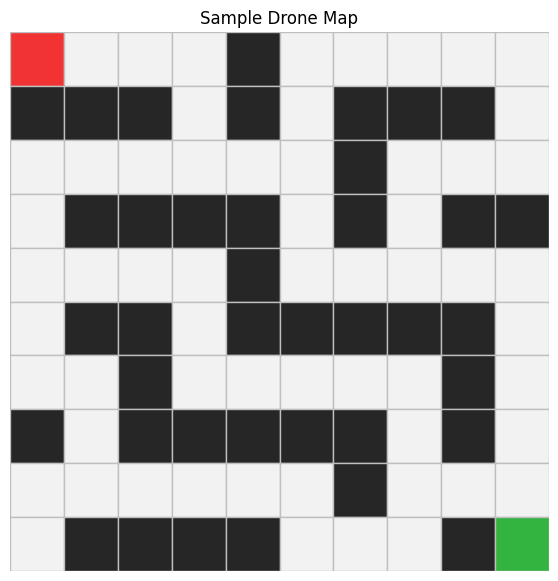

In [ ]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
#Question 8
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        #==================================#
        s = node.state

        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state = s_prime, parent = node, action = action, path_cost = cost)
        #==================================#



    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
#Question 9 BREADTH-FIRST SEARCH (BFS)
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        #==================================#
        #Step 1: Creting the initial node from problem.initial_state()
        node = Node(problem.initial_state())

        #Step 2: Checking to see if initaial state is the goal
        if problem.is_goal(node.state):
          return SearchResult(
              algorithm = algorithm,
              status = "success",
              solution = node,
              nodes_expanded = 0,
              max_frontier_size = 1,
              reached_count = 1
          )

        #Step 3: Creating a FIFO queue (deque) and adding the initial node
        frontier = deque([node])

        #Step 4: Creating a reached set and adding the initial state
        reached = {problem.initial_state()}

        #Initialisation of tracking variables.
        nodes_expanded = 0
        max_frontier_size = 1

        #Step 5: While loop for the main search
        while frontier:
          max_frontier_size = max(max_frontier_size, len(frontier)) # Updating the maximum frontier size

          node = frontier.popleft() #a. pop from the left of the FIFO deque
          nodes_expanded += 1 #b. nodes_expanded incremented
          for child in self.expand(problem, node):
            s = child.state

            #d-i. If child is goal, then return success
            if problem.is_goal(s):
              return SearchResult(
                  algorithm = algorithm,
                      status = "success",
                      solution = child,
                      nodes_expanded = nodes_expanded,
                      max_frontier_size = max_frontier_size,
                      reached_count = len(reached)
                )

            #d-ii If child.state is not in reached
            if s not in reached:
              reached.add(s) #add child.state to reached
              frontier.append(child) #Append to the back(right) of the queue


        #Step 6: Returning failure if no solution is found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
    )


        #==================================#



In [ ]:
#Question 10 DEPTH-FIRST SEARCH (DFS)
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        #======================================#
        # Step 1: Creating the initial node
        node = Node(problem.initial_state())

        # Step 2: Checking if initial state is the goal
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )

        # Step 3: Using a Python list as the stack frontier
        frontier = [node]

        # Step 4: Using a reached set
        reached = {problem.initial_state()}

        # Initialisation of tracking variables
        nodes_expanded = 0
        max_frontier_size = 1

        # Step 5: while loop for the main search
        while frontier:
            # Updating the maximum frontier size
            max_frontier_size = max(max_frontier_size, len(frontier))

            # a. Pop from the end of the list (LIFO)
            node = frontier.pop()

            # b. nodes_expanded incremented
            nodes_expanded += 1

            # c. Expanding the node
            children = list(self.expand(problem, node))

            # Reversing children to maintain MOVES order (since we're using a stack)
            children.reverse()

            # d. Adding unreached children to the stack
            for child in children:
                s = child.state

                # If child is goal, then return success
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )

                # If child.state is not in reached
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)  # Push onto stack

        # Step 6: Returning failure if no solution found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )


        #======================================#



In [ ]:
#Question 11 DEPTH-LIMITED SEARCH (DLS)
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        #====================================#

        # Step 1: Checking if the current node is goal
        if problem.is_goal(node.state):
            return (node, "success")

        # Step 2: Checking if the depth limit is reached
        if node.depth >= limit:
            return (None, "cutoff")

        # Step 3: Expanding the node
        # a. nodes_expanded incremented
        metrics["nodes_expanded"] += 1

        # b. Setting cutoff_occurred to False
        cutoff_occurred = False

        # c. For each child in expand
        for child in self.expand(problem, node):
            # i. Skip if child.state already appears on the current path
            if state_is_on_path(node, child.state):
                continue

            # ii. Updating max_stack_size
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

            # iii. Recursively call _recursive_dls on the child
            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1
            )

            # iv. If result is success,then return success immediately
            if status == "success":
                return (result, status)

            # v. If result is cutoff,then set cutoff_occurred = True
            if status == "cutoff":
                cutoff_occurred = True

        # d. After all children
        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")


        #====================================#



In [ ]:
#Question 12 INTERACTIVE DEEPENING SEARCH (IDS)
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        #===================================#
        # Requirement 1. Keep a list called iteration_log
        iteration_log = []

        # Initialising accumulators
        total_nodes_expanded = 0
        max_stack_size = 0

        # Creating DLS instance
        dls = DepthLimitedSearch()

        # Requirements 2-6. Iterating through depth limits from 0 to max_depth
        for limit in range(max_depth + 1):
            # Running DLS with current limit
            result = dls.search(problem, limit=limit)

            # Recording iteration information
            iteration_info = {
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            }
            iteration_log.append(iteration_info)

            # Requirement 2. Accumulate total nodes expanded
            total_nodes_expanded += result.nodes_expanded

            # Requirement 3. Track maximum stack size
            max_stack_size = max(max_stack_size, result.max_frontier_size)

            # Requirement 4. If success,then return IDS result
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,  # DLS uses path-cycle checking, not reached set
                    iterations=iteration_log
                )

            # Requirement 5. If failure,then stop early
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    iterations=iteration_log
                )

        # Requirement 6. If all limits return cutoff,then return cutoff
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log
        )


        #===================================#



In [ ]:
#Question 13 Running algorithms on a sample map
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


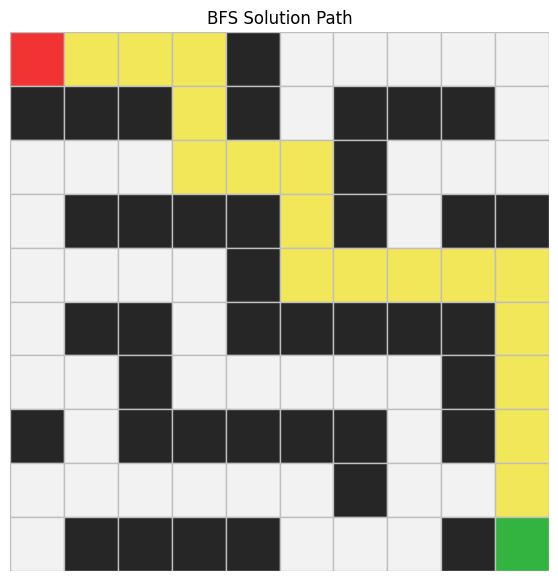

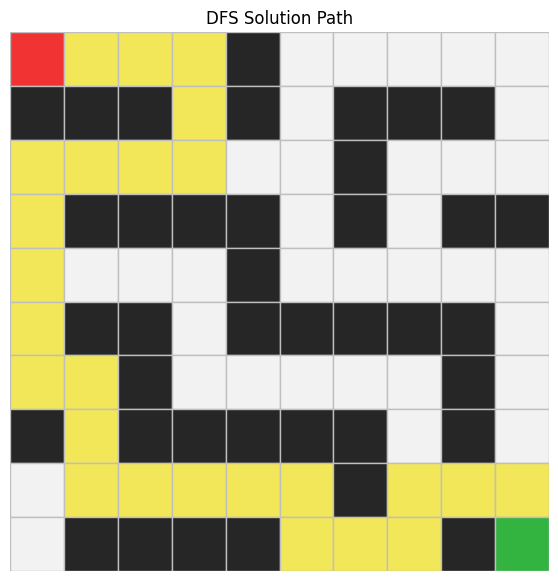

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

Custom Map 1 - Long Corridor with Obstacles


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28.0,28.0,117,9,123
1,DFS,success,NaN,90.0,90.0,106,10,115
2,DLS,cutoff,20.0,NaN,NaN,123,21,0
3,IDS,success,NaN,28.0,28.0,5293,29,0


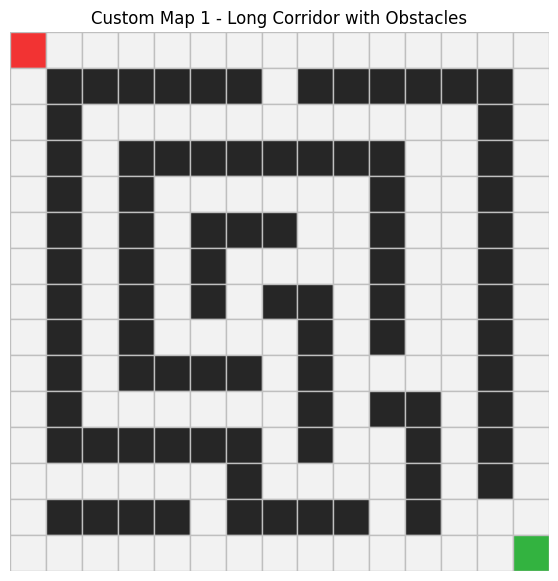

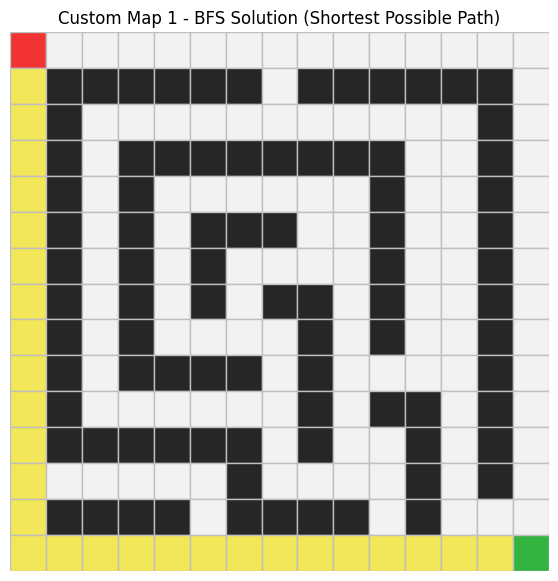

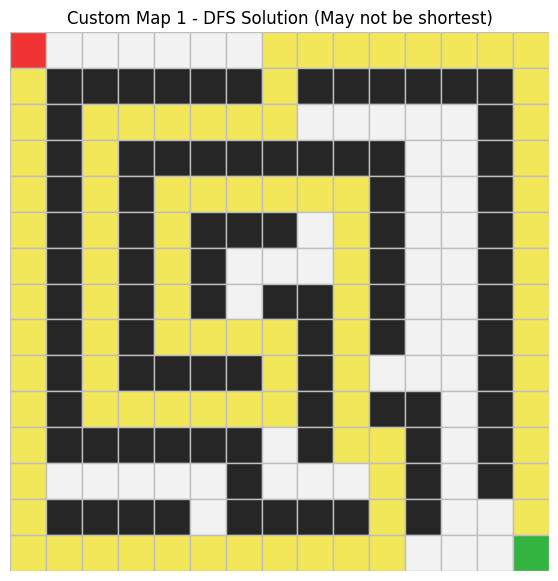

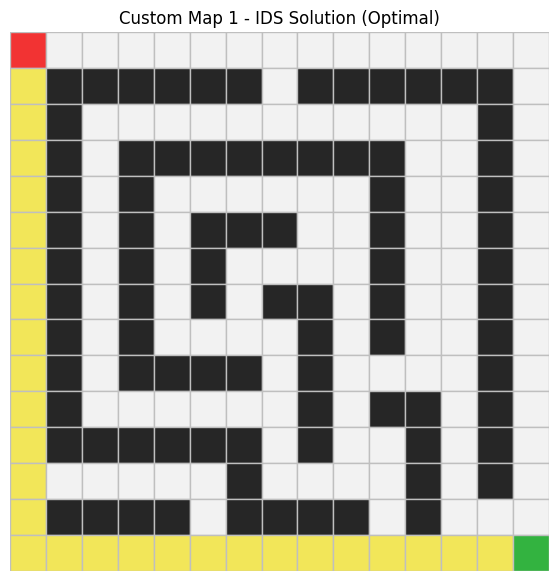


DLS returned 'cutoff' with limit=20 — no path to visualise.
This is expected behaviour when the depth limit is smaller than the solution depth.

Interpretation of Custom Map 1:
 This map has a long, winding corridor created by horizontal walls
 BFS found the optimal path in 28 steps
 DFS found a path in 90 steps (whichcmay not be optimal)
 DLS with limit=20 returned cutoff — solution depth is greater than 20
 IDS found the optimal path in 28 steps


In [41]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)


#==========================================#

#Problem creation 1
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=28),
]

#Results display
print("Custom Map 1 - Long Corridor with Obstacles")
print("=" * 50)
display(show_results(custom_results_1))

#Visualisation of solution paths
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    title="Custom Map 1 - Long Corridor with Obstacles"
)

#BFS DFS and IDS visualisation
bfs_result_1 = custom_results_1[0]
dfs_result_1 = custom_results_1[1]
ids_result_1 = custom_results_1[3]

if bfs_result_1.solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=bfs_result_1.path,
        title="Custom Map 1 - BFS Solution (Shortest Possible Path)"
    )

if dfs_result_1.solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=dfs_result_1.path,
        title="Custom Map 1 - DFS Solution (May not be shortest)"
    )

if ids_result_1.solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=ids_result_1.path,
        title="Custom Map 1 - IDS Solution (Optimal)"
    )

dls_result_1 = custom_results_1[2]

if dls_result_1.solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=dls_result_1.path,
        title="Custom Map 1 - DLS Solution"
    )
else:
    print()
    print(f"DLS returned '{dls_result_1.status}' with limit=20 — no path to visualise.")
    print("This is expected behaviour when the depth limit is smaller than the solution depth.")


# Interpretation
print("\nInterpretation of Custom Map 1:")
print(" This map has a long, winding corridor created by horizontal walls")
print(f" BFS found the optimal path in {bfs_result_1.solution_depth} steps")
print(f" DFS found a path in {dfs_result_1.solution_depth} steps (whichcmay not be optimal)")
print(f" DLS with limit = 20 returned cutoff — solution depth is greater than 20")
print(f" IDS found the optimal path in {ids_result_1.solution_depth} steps")

#==========================================#

In [39]:
bfs_check = bfs.search(GridProblem(custom_grid_1, custom_start_1, custom_goal_1))
print("BFS depth:", bfs_check.solution_depth)

BFS depth: 28


Custom Map 2 - Large 20x20 Complex Environment
____________________________________________________________


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,38.0,38.0,153,7,158
1,DFS,success,NaN,78.0,78.0,95,8,102
2,DLS,cutoff,30.0,NaN,NaN,298,31,0
3,DLS,success,50.0,50.0,50.0,99,51,0
4,IDS,success,NaN,38.0,38.0,5690,39,0


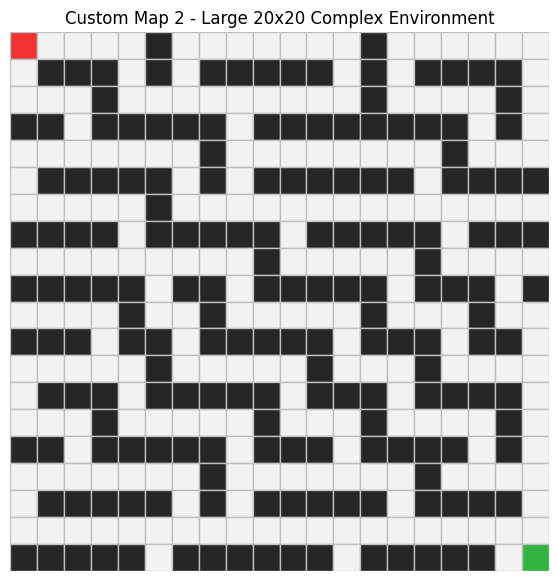

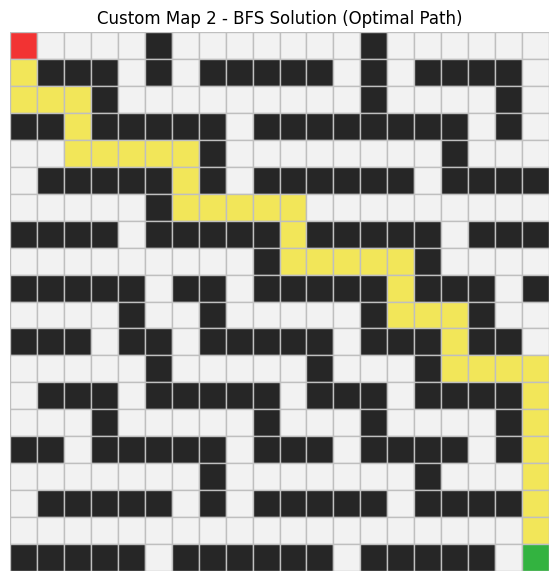

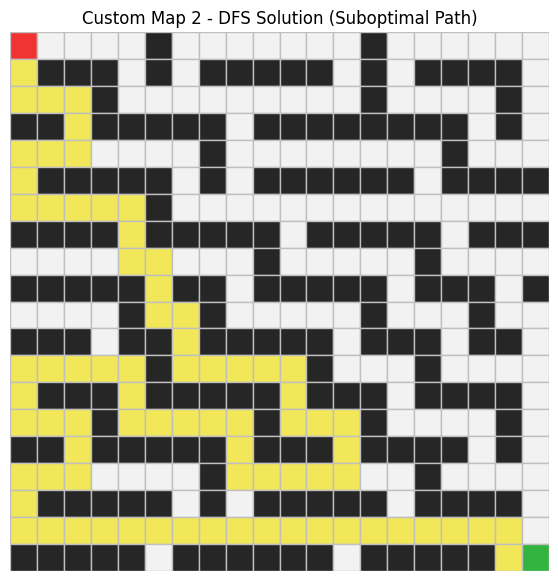

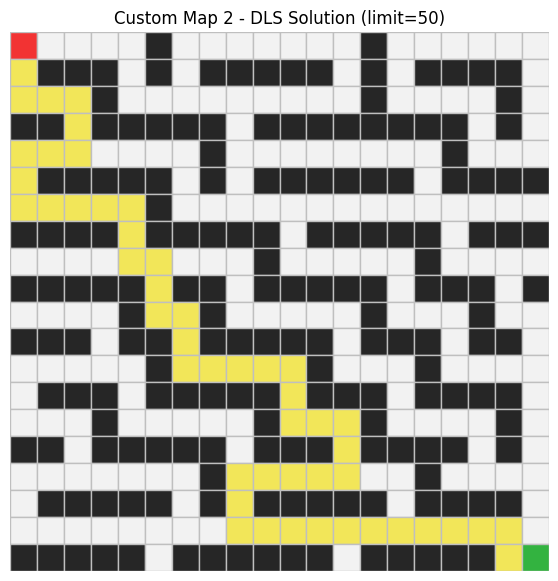

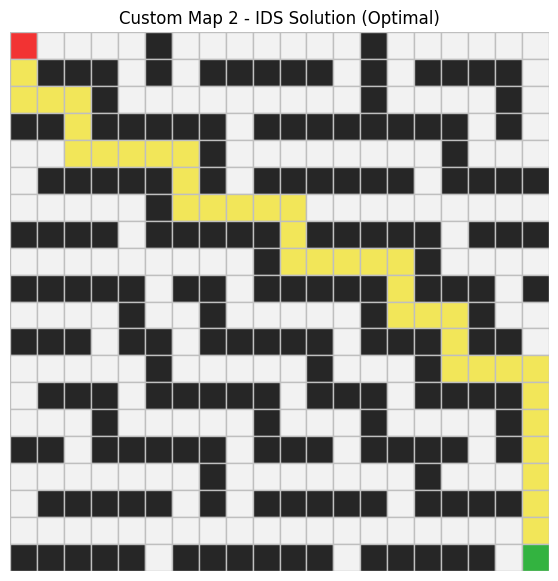

INTERPRETATION OF CUSTOM MAP 2
____________________________________________________________

Characteristics of the map:
 This is a 20x20 grid with complex obstacle patterns
 It has multiple potential paths with varying lengths
 and also dead ends and loops to challenge DFS
 The large open areas are mixed with narrow corridors
 This map is designed to highlight differences between algorithms

Expected Algorithm Behaviors:
____________________________________________________________

1. Breadth-First Search - BFS :
   This finds the most optimal (shortest) path
   It explores level by level
   It may use significant memory for the frontier
    -Nodes expanded: 153
    -Path length: 38

2. Depth-First Search - DFS:
    This search explores deeply, to find suboptimal path
    It generally uses less memory than BFS
    It has the tendency to explore many dead ends first
    - Nodes expanded: 95
    - Path length: 78

3. Depth-Limited Search - DLS:
     With limit = 20: CUTOFF - limit too s

In [42]:
# TODO 11:
# Create your second custom map here.
# Map 2: Large 20x20 complex environment with multiple obstacles, dead ends, and open areas

custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

# Problem Creation
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

# Testing with different DLS limits to show the effect of depth limits
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=30),  # Too small
    dls.search(custom_problem_2, limit=50),  # Should be enough
    ids.search(custom_problem_2, max_depth= 60),
]

# Results display
print("Custom Map 2 - Large 20x20 Complex Environment")
print("_" * 60)
display(show_results(custom_results_2))

# Visualising the the empty map
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    title = "Custom Map 2 - Large 20x20 Complex Environment"
)

# Visualising the BFS solution
bfs_result_2 = custom_results_2[0]
if bfs_result_2.solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path = bfs_result_2.path,
        title = "Custom Map 2 - BFS Solution (Optimal Path)"
    )

# Visualising the DFS solution
dfs_result_2 = custom_results_2[1]
if dfs_result_2.solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path = dfs_result_2.path,
        title = "Custom Map 2 - DFS Solution (Suboptimal Path)"
    )

# Visualising the successful DLS solution (limit = 35)
dls_success = custom_results_2[3]  # DLS with limit = 50
if dls_success.solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path = dls_success.path,
        title = "Custom Map 2 - DLS Solution (limit=50)"
    )

# Visualising the IDS solution
ids_result_2 = custom_results_2[4]
if ids_result_2.solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path = ids_result_2.path,
        title = "Custom Map 2 - IDS Solution (Optimal)"
    )

# Detailed interpretation
print("INTERPRETATION OF CUSTOM MAP 2")
print("_" * 60)
print("\nCharacteristics of the map:")
print(" This is a 20x20 grid with complex obstacle patterns")
print(" It has multiple potential paths with varying lengths")
print(" and also dead ends and loops to challenge DFS")
print(" The large open areas are mixed with narrow corridors")
print(" This map is designed to highlight differences between algorithms")

print("\nExpected Algorithm Behaviors:")
print("_" * 60)
print()
print("1. Breadth-First Search - BFS :")
print("   This finds the most optimal (shortest) path")
print("   It explores level by level")
print("   It may use significant memory for the frontier")
print(f"    -Nodes expanded: {bfs_result_2.nodes_expanded}")
print(f"    -Path length: {bfs_result_2.solution_depth}")

print("\n2. Depth-First Search - DFS:")
print("    This search explores deeply, to find suboptimal path")
print("    It generally uses less memory than BFS")
print("    It has the tendency to explore many dead ends first")
print(f"    - Nodes expanded: {dfs_result_2.nodes_expanded}")
print(f"    - Path length: {dfs_result_2.solution_depth}")

print("\n3. Depth-Limited Search - DLS:")
print("     With limit = 20: ", end="")
dls_fail = custom_results_2[2]
if dls_fail.status == "cutoff":
    print("CUTOFF - limit too small to reach goal")
elif dls_fail.status == "success":
    print(f"Found solution of length {dls_fail.solution_depth}")
print("   - With limit=50: ", end="")
if dls_success.status == "success":
    print(f"Found solution of length {dls_success.solution_depth}")
print("   - Shows how depth limits affect completeness")

print("\n4. Iterative Deepening Search - IDS:")
print("   This search type combines benefits and optimaity of both DFS and BFS")
print("   It seeks to find optimal solutions like BFS")
print("   and also uses memory efficiently just like DFS")
print(f"     - Total nodes expanded: {ids_result_2.nodes_expanded}")
print(f"     - Path length: {ids_result_2.solution_depth}")

print("\nKey Observations:")
print("  BFS expanded the most nodes but guaranteed the shortest path")
print("  BFS found the optimal path in 38 steps using 153 nodes expanded")
print("  DFS found a path in 78 steps — exactly double the optimal length")
print("  DFS only expanded 95 nodes but the path was significantly suboptimal")
print("  DLS with limit = 30 returned cutoff — the solution is deeper than 30 steps")
print("  DLS with limit = 50 found a solution of depth 50 — longer than optimal")
print("  IDS found the optimal path of 38 steps like BFS but expanded 5690 nodes total")
print("  IDS used far more node expansions due to repeated re-expansion at each depth level")
print("  The reached/explored set in BFS and DFS prevents revisiting states")
print("  DLS uses path-cycle checking instead, which is why reached states shows 0")
print("  All these observations were made using the table ")